In [ ]:
!pip install tensorflow pandas scikit-learn

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel('balanced_edufeed_dataset.xlsx')
df = df[['comments', 'sentiment_label']].dropna()

In [5]:
X = df['comments'].astype(str)
y = df['sentiment_label']

In [6]:
le = LabelEncoder()
y = le.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5
)

In [8]:
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_ds = train_ds.batch(128)
val_ds   = val_ds.batch(128)

In [9]:
X_train = np.array(X_train, dtype=str)
X_val   = np.array(X_val, dtype=str)
X_test  = np.array(X_test, dtype=str)

In [10]:
X_train = X_train.reshape(-1)
X_val   = X_val.reshape(-1)
X_test  = X_test.reshape(-1)

In [11]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=20000,
    output_sequence_length=100
)
vectorizer.adapt(X_train)

In [12]:
inputs = tf.keras.Input(shape=(), dtype=tf.string)
x = vectorizer(inputs)
x = tf.keras.layers.Embedding(20000, 64)(x)
x = tf.keras.layers.SpatialDropout1D(0.2)(x)
x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(64, return_sequences=True)
)(x)
x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(32)
)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    )
]

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 69s 357ms/step - accuracy: 0.6174 - loss: 0.8326 - val_accuracy: 0.7212 - val_loss: 0.6590 - learning_rate: 0.0010
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 66s 340ms/step - accuracy: 0.7882 - loss: 0.5456 - val_accuracy: 0.7913 - val_loss: 0.5471 - learning_rate: 0.0010
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 82s 337ms/step - accuracy: 0.8519 - loss: 0.3989 - val_accuracy: 0.8255 - val_loss: 0.4988 - learning_rate: 0.0010
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 66s 343ms/step - accuracy: 0.8789 - loss: 0.3252 - val_accuracy: 0.8295 - val_loss: 0.5065 - learning_rate: 0.0010
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 71s 364ms/step - accuracy: 0.8981 - loss: 0.2669 - val_accuracy: 0.8357 - val_loss: 0.4983 - learning_rate: 0.0010
Epoch 6/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 66s 339ms/step - accuracy: 0.9122 - loss: 0.2295 - val_accuracy: 0.8524 - val_loss: 0.4785 - learning_rate: 0.0010
Epoch 7/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 63s 326ms/step - accuracy: 0.9

In [17]:
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(128)
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.8455 - loss: 0.4931
Test Accuracy: 0.8454733490943909


In [18]:
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_classes))

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1779
           1       0.82      0.89      0.85      1752
           2       0.88      0.76      0.82      1782

    accuracy                           0.85      5313
   macro avg       0.85      0.85      0.84      5313
weighted avg       0.85      0.85      0.84      5313



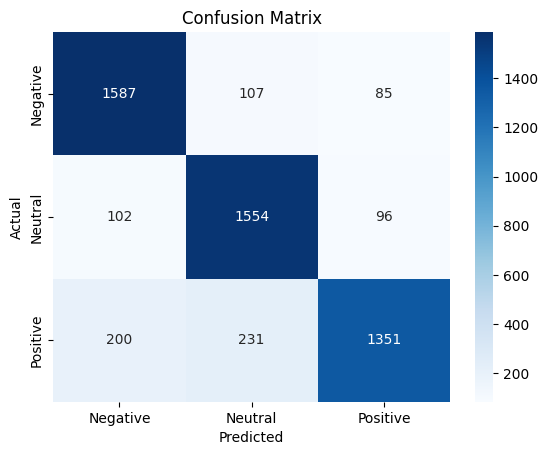

In [19]:
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()